In [7]:
%load_ext autoreload
%autoreload 2

from database.manager import DatabaseManager
from analysis.seasonality import Seasonality
from analysis.plotting import SeasonalityPlotter
from analysis.feature_creation import FeatureCreator
from Mini_Tools.export_to_excel import export_to_excel
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from analysis.trend_score import get_stability_metrics

db = DatabaseManager()
sznlty = Seasonality(db)
plotter = SeasonalityPlotter()
fc = FeatureCreator()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
result = sznlty.working_day_expression_seasonality("CO", "J27 - 3*M27 + 3*Q27 - V27 ", start_year=2014, end_year=2027, window_days=350)
plotter.plot_seasonality(result, title="seasonality")
export_to_excel(result, filename="seasonality_report_final.xlsx")

✅ Data successfully exported to seasonality_report_final.xlsx


In [21]:
# Call the function
metrics = get_stability_metrics(
    sznlty=sznlty, 
    symbol="CO", 
    expression="J27 - 3*M27 + 3*Q27 - V27", 
    start_year=2014, 
    end_year=2027, 
    window_days=350,
    threshold=0.1  # Optional: defaults are already set in the function
)

# 1. Print the Final Scores
print(f"Latest Year Score: {metrics['latest_score']}")
print(f"General Trend Score: {metrics['trend_score']}")

Latest Year Score: 80.0
General Trend Score: 88.7


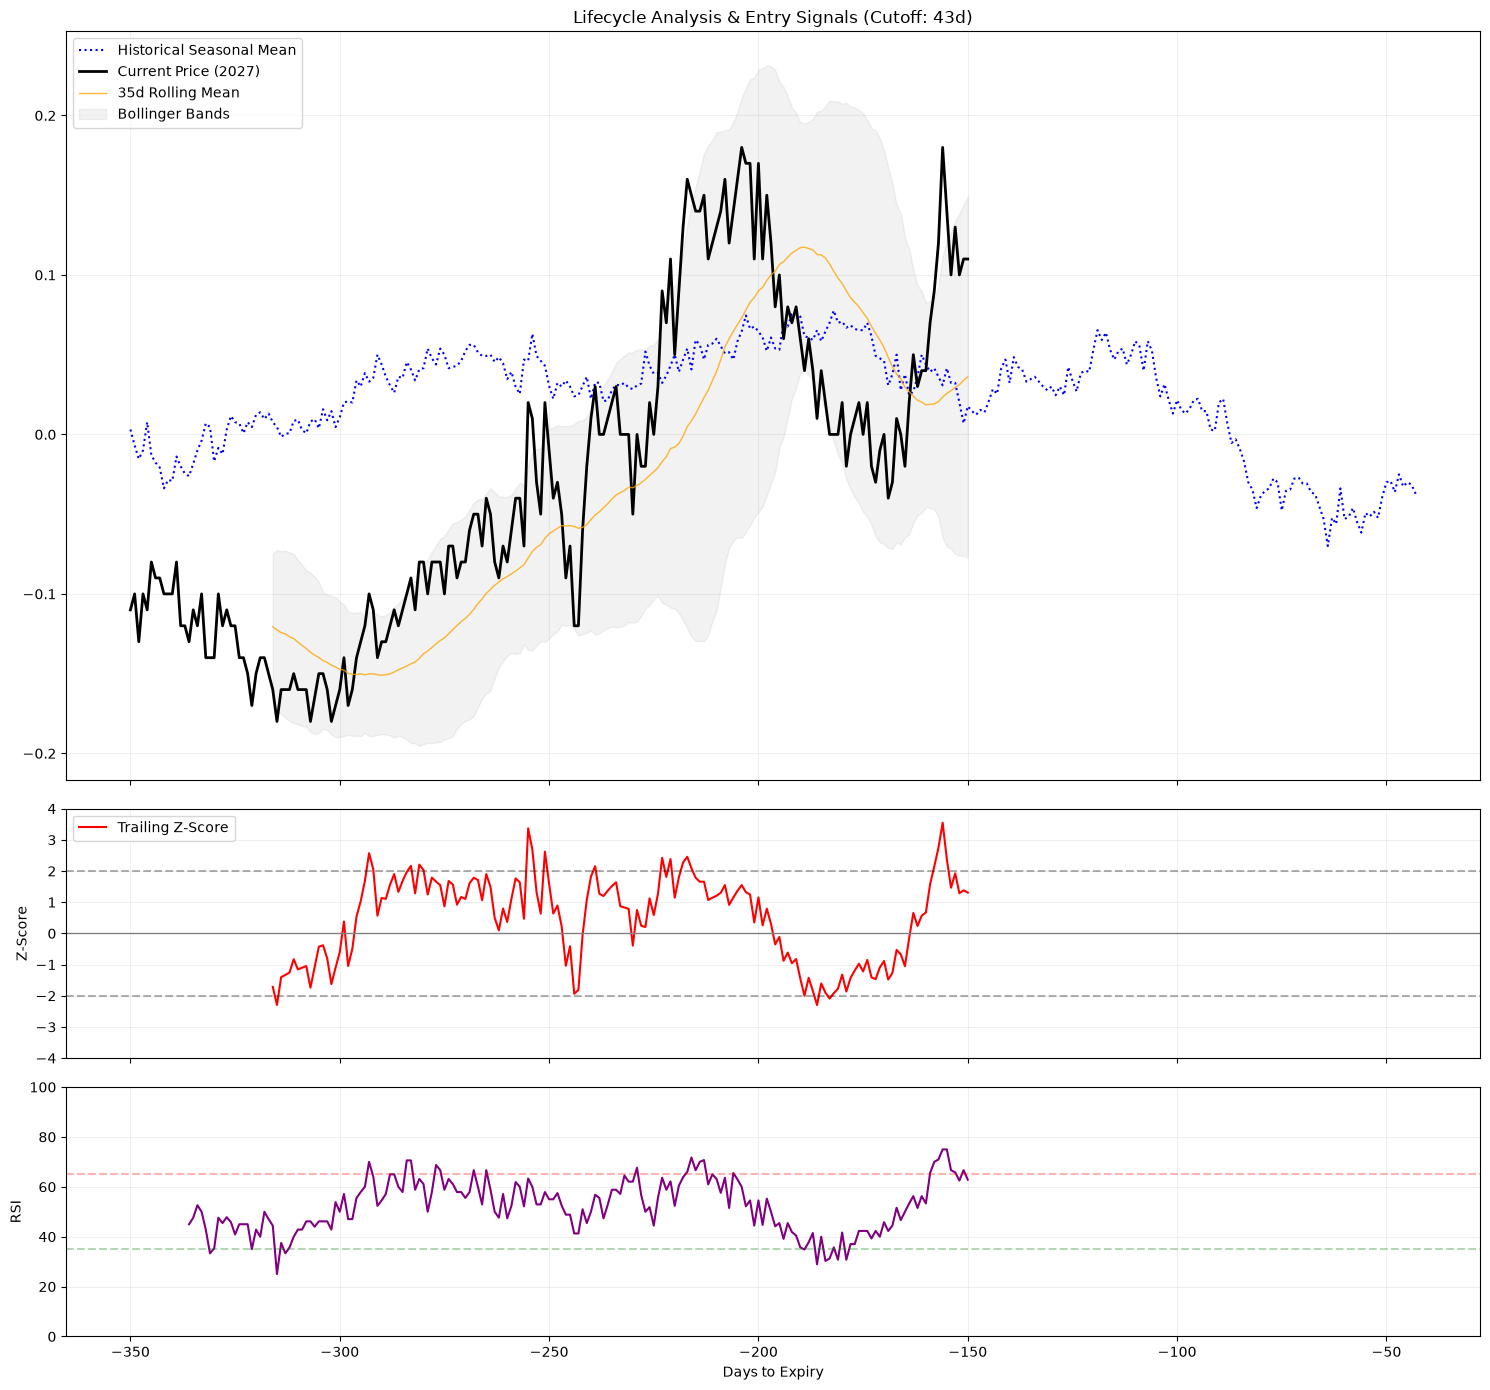

,z_score,rsi
-350,NaN,NaN
-349,NaN,NaN
-348,NaN,NaN
-347,NaN,NaN
-346,NaN,NaN
...,...,...
-154,1.464683,66.666667
-153,1.925160,65.789474
-152,1.285480,62.500000
-151,1.380544,66.666667


In [24]:
def plot_technical_with_cutoff(result, window_bb=35, window_rsi=14, cutoff=43):
    # 1. Filter data to exclude everything after the cutoff
    df_full = result['combined'].sort_index()
    df = df_full[df_full.index <= -cutoff] 
    
    year_cols = [c for c in df.columns if str(c).isdigit() and len(str(c)) == 4]
    latest_year = max(year_cols)
    hist_years = [c for c in year_cols if c != latest_year]
    
    # 2. Extract series and DROP NaNs
    full_index = df.index
    latest_series = df[latest_year].dropna()
    hist_mean = df[hist_years].mean(axis=1)
    
    # 3. Indicators
    sma = latest_series.rolling(window=window_bb).mean()
    std = latest_series.rolling(window=window_bb).std()
    
    # Option C: Trailing Z-Score
    z_score = (latest_series - sma) / std
    
    # RSI Calculation
    delta = latest_series.diff()
    gain = delta.clip(lower=0).rolling(window_rsi).mean()
    loss = (-delta.clip(upper=0)).rolling(window_rsi).mean()
    rs = gain / loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    rsi.loc[(loss == 0) & (gain > 0)] = 100

    # 4. Plotting (3 Subplots)
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True, 
                                        gridspec_kw={'height_ratios': [3, 1, 1]})
    
    # --- Chart 1: Price, Historical Mean, SMA, and BB ---
    ax1.plot(full_index, hist_mean, label='Historical Seasonal Mean', color='blue', linestyle=':', lw=1.5)
    ax1.plot(latest_series.index, latest_series, label=f'Current Price ({latest_year})', color='black', lw=2)
    ax1.plot(sma.index, sma, label=f'{window_bb}d Rolling Mean', color='orange', lw=1, alpha=0.8)
    ax1.fill_between(latest_series.index, sma - (std * 2), sma + (std * 2), color='gray', alpha=0.1, label='Bollinger Bands')
    ax1.set_title(f"Lifecycle Analysis & Entry Signals (Cutoff: {cutoff}d)")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.2)

    # --- Chart 2: Trailing Z-Score (Option C) ---
    ax2.plot(z_score.index, z_score, color='red', label='Trailing Z-Score')
    ax2.axhline(2, color='black', linestyle='--', alpha=0.3)
    ax2.axhline(-2, color='black', linestyle='--', alpha=0.3)
    ax2.axhline(0, color='gray', lw=1)
    ax2.set_ylabel("Z-Score")
    ax2.set_ylim(-4, 4)
    ax2.grid(True, alpha=0.2)
    ax2.legend(loc='upper left')

    # --- Chart 3: RSI ---
    ax3.plot(rsi.index, rsi, color='purple', label='RSI')
    ax3.axhline(65, color='red', linestyle='--', alpha=0.3)
    ax3.axhline(35, color='green', linestyle='--', alpha=0.3)
    ax3.set_ylim(0, 100)
    ax3.set_ylabel("RSI")
    ax3.grid(True, alpha=0.2)
    
    plt.xlabel("Days to Expiry")
    plt.tight_layout()
    plt.show()
    return pd.DataFrame({
    "z_score": z_score,
    "rsi": rsi,
    })

# Execution
plot_technical_with_cutoff(metrics['raw_result'])

In [4]:
# Capture the Z-score and RSI calculated by the plotting function
df = plot_technical_with_cutoff(metrics["raw_result"])

upper_rsi = 65
lower_rsi = 35
z_score_slippage = 1.75

upper_signal = (
    (df["z_score"] >= z_score_slippage)
    & (df["rsi"] >= upper_rsi)
)

lower_signal = (
    (df["z_score"] <= -z_score_slippage)
    & (df["rsi"] <= lower_rsi)
)

# -1 = upper/sell, +1 = lower/buy, 0 = no signal
df["signal"] = np.select(
    [upper_signal, lower_signal],
    [-1, 1],
    default=0,
)

NameError: name 'metrics' is not defined

In [32]:
df.loc[df["signal"] != 0, ["z_score", "rsi", "signal"]]

,z_score,rsi,signal
-331,-1.764535,33.333333,1
-321,-2.230854,35.000000,1
-315,-2.038133,25.000000,1
-293,2.714103,70.000000,-1
-268,2.044953,66.666667,-1
-265,2.083540,66.666667,-1
-217,2.238921,66.000000,-1
-216,1.767639,71.739130,-1
-186,-1.774271,28.947368,1
-159,2.141889,65.517241,-1


In [1]:
import pandas as pd

from database.manager import DatabaseManager
from analysis.seasonality import Seasonality
from backtesting.engine import SeasonalBacktester
from backtesting.strategies import SeasonalStrategies


# ---------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------
symbol = "CO"
expression = "J27 - 3*M27 + 3*Q27 - V27"

data_start_year = 2016
data_end_year = 2027
test_start_year = 2020
window_days = 350


# ---------------------------------------------------------
# 2. Fetch and construct the raw seasonal data
# ---------------------------------------------------------
db = DatabaseManager()

try:
    seasonality = Seasonality(db)

    result = seasonality.working_day_expression_seasonality(
        symbol=symbol,
        expression=expression,
        start_year=data_start_year,
        end_year=data_end_year,
        window_days=window_days,
    )

    if result["combined"].empty:
        raise ValueError(
            f"No seasonal data was created. Warnings: {result.get('warnings', [])}"
        )

    print("Available years:", list(result["combined"].columns))
    print("Seasonal matrix shape:", result["combined"].shape)

    for warning in result.get("warnings", []):
        print("Warning:", warning)


    # ---------------------------------------------------------
    # 3. Initialize the walk-forward backtester
    # ---------------------------------------------------------
    backtester = SeasonalBacktester(result)


    # ---------------------------------------------------------
    # 4. Run the Z-score and RSI strategy
    #
    # LONG:
    #   Z-score <= -1.75 and RSI <= 35
    #
    # SHORT:
    #   Z-score >= 1.75 and RSI >= 65
    #
    # Holding period:
    #   6 working days
    #
    # Only one position can be open at a time.
    # ---------------------------------------------------------
    trade_history = backtester.run_walk_forward(
        strategy_func=SeasonalStrategies.technical_zscore_rsi,
        data_start_year=data_start_year,
        test_start_year=test_start_year,
    )


    # ---------------------------------------------------------
    # 5. Display results
    # ---------------------------------------------------------
    if trade_history.empty:
        print("\nNo trades were generated.")
    else:
        display_columns = [
            "Entry_Date",
            "Test_Year",
            "Day_to_Expiry",
            "Signal",
            "Duration",
            "Entry_Price",
            "Exit_Price",
            "Price_Move",
            "Success",
            "TECH_ZScore",
            "TECH_RSI",
        ]

        print("\nTrade history:")
        display(trade_history[display_columns])

        total_trades = len(trade_history)
        successful_trades = int(trade_history["Success"].sum())
        success_rate = trade_history["Success"].mean() * 100
        total_price_move = trade_history["Price_Move"].sum()
        average_price_move = trade_history["Price_Move"].mean()

        print("\nBacktest summary")
        print("----------------")
        print(f"Expression:         {expression}")
        print(f"Total trades:       {total_trades}")
        print(f"Successful trades:  {successful_trades}")
        print(f"Success rate:       {success_rate:.2f}%")
        print(f"Total price move:   {total_price_move:.4f}")
        print(f"Average price move: {average_price_move:.4f}")

        print("\nResults by signal:")
        display(
            trade_history.groupby("Signal").agg(
                Trades=("Success", "size"),
                Successful_Trades=("Success", "sum"),
                Success_Rate=("Success", lambda x: x.mean() * 100),
                Total_Price_Move=("Price_Move", "sum"),
                Average_Price_Move=("Price_Move", "mean"),
            )
        )

        print("\nResults by test year:")
        display(
            trade_history.groupby("Test_Year").agg(
                Trades=("Success", "size"),
                Successful_Trades=("Success", "sum"),
                Success_Rate=("Success", lambda x: x.mean() * 100),
                Total_Price_Move=("Price_Move", "sum"),
                Average_Price_Move=("Price_Move", "mean"),
            )
        )

finally:
    db.close()

Available years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027]
Seasonal matrix shape: (351, 12)

Trade history:


,Entry_Date,Test_Year,Day_to_Expiry,Signal,Duration,Entry_Price,Exit_Price,Price_Move,Success,TECH_ZScore,TECH_RSI
0,2018-11-23,2020,-330,LONG,5,-0.17,-0.08,0.09,1,-3.527482,30.434783
1,2019-04-09,2020,-233,SHORT,5,0.11,0.06,0.05,1,2.647230,69.565217
2,2019-05-24,2020,-200,LONG,5,0.00,0.00,0.00,0,-2.327878,33.333333
3,2019-09-03,2020,-128,SHORT,5,0.07,0.09,-0.02,0,2.295332,71.428571
4,2019-09-16,2020,-119,SHORT,5,0.17,0.07,0.10,1,2.919548,68.571429
...,...,...,...,...,...,...,...,...,...,...,...
58,2025-12-12,2027,-315,LONG,5,-0.18,-0.16,0.02,1,-2.038133,25.000000
59,2026-01-13,2027,-293,SHORT,5,-0.10,-0.12,0.02,1,2.714103,70.000000
60,2026-02-17,2027,-268,SHORT,5,-0.05,-0.08,0.03,1,2.044953,66.666667
61,2026-04-29,2027,-217,SHORT,5,0.16,0.11,0.05,1,2.238921,66.000000



Backtest summary
----------------
Expression:         J27 - 3*M27 + 3*Q27 - V27
Total trades:       63
Successful trades:  44
Success rate:       69.84%
Total price move:   1.2150
Average price move: 0.0193

Results by signal:


,Trades,Successful_Trades,Success_Rate,Total_Price_Move,Average_Price_Move
Signal,,,,,
LONG,30,21,70.00000,0.520,0.017333
SHORT,33,23,69.69697,0.695,0.021061



Results by test year:


,Trades,Successful_Trades,Success_Rate,Total_Price_Move,Average_Price_Move
Test_Year,,,,,
2020,7,4,57.142857,0.240,0.034286
2021,9,6,66.666667,0.220,0.024444
2022,13,9,69.230769,0.220,0.016923
2023,11,6,54.545455,-0.015,-0.001364
2024,6,4,66.666667,0.110,0.018333
2025,5,5,100.000000,0.160,0.032000
2026,6,5,83.333333,0.180,0.030000
2027,6,5,83.333333,0.100,0.016667


In [13]:
from database.manager import DatabaseManager
from analysis.seasonality import Seasonality
from backtesting.risk_engine import RiskManagedBacktester
from backtesting.strategies import SeasonalStrategies

db = DatabaseManager()
seasonality = Seasonality(db)

result = seasonality.working_day_expression_seasonality(
    symbol="CO",
    expression="J27 - 3*M27 + 3*Q27 - V27",
    start_year=2012,
    end_year=2027,
    window_days=350,
)

backtester = RiskManagedBacktester(result)

trades = backtester.run_walk_forward(
    strategy_func=SeasonalStrategies.technical_zscore_rsi,
    data_start_year=2012,
    test_start_year=2020,
    max_hold_days=6,
    stop_loss=0.03,
    take_profit=0.03,
)

display(trades)
trades.describe
db.close()

,Entry_Date,Test_Year,Day_to_Expiry,Signal,Entry_Price,Max_Hold,Stop_Loss,Take_Profit,2012,2013,...,Price_Move,Exit_Reason,Success,2021,2022,2023,2024,2025,2026,2027
0,2018-11-23,2020,-330,LONG,-0.17,6,0.03,0.03,-0.05,-4.263256e-14,...,0.09,TAKE_PROFIT,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-04-09,2020,-233,SHORT,0.11,6,0.03,0.03,0.09,5.684342e-14,...,0.03,TAKE_PROFIT,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-05-24,2020,-200,LONG,0.00,6,0.03,0.03,0.10,1.500000e-01,...,0.04,TAKE_PROFIT,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-09-03,2020,-128,SHORT,0.07,6,0.03,0.03,0.19,1.200000e-01,...,0.01,MAX_HOLD,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-09-16,2020,-119,SHORT,0.17,6,0.03,0.03,0.26,8.000000e-02,...,0.04,TAKE_PROFIT,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,2026-01-13,2027,-293,SHORT,-0.10,6,0.03,0.03,-0.02,5.000000e-02,...,0.04,TAKE_PROFIT,1,-0.02,9.000000e-02,0.05,-0.09,-0.05,-0.02,-0.10
65,2026-02-17,2027,-268,SHORT,-0.05,6,0.03,0.03,0.03,1.500000e-01,...,0.03,TAKE_PROFIT,1,0.07,-4.263256e-14,0.09,-0.05,-0.01,0.01,-0.05
66,2026-04-29,2027,-217,SHORT,0.16,6,0.03,0.03,-0.03,8.000000e-02,...,0.05,TAKE_PROFIT,1,-0.14,3.000000e-02,0.06,-0.06,0.05,-0.07,0.16
67,2026-07-20,2027,-159,SHORT,0.07,6,0.03,0.03,0.10,1.200000e-01,...,-0.05,STOP_LOSS,0,-0.01,2.842171e-14,0.10,-0.05,0.03,-0.07,0.07


In [14]:
# Present backtest results
if trades.empty:
    print("No trades were generated.")
else:
    display_columns = [
        "Entry_Date",
        "Exit_Date",
        "Test_Year",
        "Day_to_Expiry",
        "Exit_Day",
        "Signal",
        "Entry_Price",
        "Exit_Price",
        "Price_Move",
        "Days_Held",
        "Exit_Reason",
        "TECH_ZScore",
        "TECH_RSI",
        "Success",
    ]

    available_columns = [
        column for column in display_columns
        if column in trades.columns
    ]

    trade_view = trades[available_columns].copy()

    numeric_columns = [
        "Entry_Price",
        "Exit_Price",
        "Price_Move",
        "TECH_ZScore",
        "TECH_RSI",
    ]

    for column in numeric_columns:
        if column in trade_view.columns:
            trade_view[column] = trade_view[column].round(3)

    print("TRADE HISTORY")
    display(
        trade_view.style
        .format({
            "Entry_Price": "{:.3f}",
            "Exit_Price": "{:.3f}",
            "Price_Move": "{:+.3f}",
            "TECH_ZScore": "{:.2f}",
            "TECH_RSI": "{:.2f}",
        }, na_rep="-")
        .background_gradient(
            subset=["Price_Move"],
            cmap="RdYlGn",
        )
    )

    summary = pd.DataFrame({
        "Metric": [
            "Total Trades",
            "Winning Trades",
            "Losing Trades",
            "Success Rate",
            "Total Price Move",
            "Average Price Move",
            "Average Days Held",
            "Largest Winner",
            "Largest Loss",
        ],
        "Value": [
            len(trades),
            int((trades["Price_Move"] > 0).sum()),
            int((trades["Price_Move"] <= 0).sum()),
            f"{trades['Success'].mean() * 100:.2f}%",
            round(trades["Price_Move"].sum(), 3),
            round(trades["Price_Move"].mean(), 3),
            round(trades["Days_Held"].mean(), 2),
            round(trades["Price_Move"].max(), 3),
            round(trades["Price_Move"].min(), 3),
        ],
    })

    print("\nOVERALL SUMMARY")
    display(summary.style.hide(axis="index"))

    print("\nRESULTS BY EXIT REASON")
    exit_summary = (
        trades.groupby("Exit_Reason")
        .agg(
            Trades=("Price_Move", "size"),
            Winners=("Success", "sum"),
            Success_Rate=("Success", "mean"),
            Total_Move=("Price_Move", "sum"),
            Average_Move=("Price_Move", "mean"),
            Average_Hold=("Days_Held", "mean"),
        )
    )

    exit_summary["Success_Rate"] *= 100

    display(
        exit_summary.style.format({
            "Success_Rate": "{:.2f}%",
            "Total_Move": "{:+.3f}",
            "Average_Move": "{:+.3f}",
            "Average_Hold": "{:.2f}",
        })
    )

    print("\nRESULTS BY YEAR")
    yearly_summary = (
        trades.groupby("Test_Year")
        .agg(
            Trades=("Price_Move", "size"),
            Winners=("Success", "sum"),
            Success_Rate=("Success", "mean"),
            Total_Move=("Price_Move", "sum"),
            Average_Move=("Price_Move", "mean"),
        )
    )

    yearly_summary["Success_Rate"] *= 100

    display(
        yearly_summary.style.format({
            "Success_Rate": "{:.2f}%",
            "Total_Move": "{:+.3f}",
            "Average_Move": "{:+.3f}",
        })
    )

TRADE HISTORY


,Entry_Date,Exit_Date,Test_Year,Day_to_Expiry,Exit_Day,Signal,Entry_Price,Exit_Price,Price_Move,Days_Held,Exit_Reason,TECH_ZScore,TECH_RSI,Success
0,2018-11-23,2018-11-26,2020,-330,-329,LONG,-0.170,-0.080,+0.090,1,TAKE_PROFIT,-3.53,30.43,1
1,2019-04-09,2019-04-12,2020,-233,-230,SHORT,0.110,0.080,+0.030,3,TAKE_PROFIT,2.65,69.56,1
2,2019-05-24,2019-05-30,2020,-200,-196,LONG,0.000,0.040,+0.040,4,TAKE_PROFIT,-2.33,33.33,1
3,2019-09-03,2019-09-11,2020,-128,-122,SHORT,0.070,0.060,+0.010,6,MAX_HOLD,2.29,71.43,1
4,2019-09-16,2019-09-17,2020,-119,-118,SHORT,0.170,0.130,+0.040,1,TAKE_PROFIT,2.92,68.57,1
5,2019-11-14,2019-11-22,2020,-76,-70,LONG,-0.010,-0.010,+0.000,6,MAX_HOLD,-2.06,31.43,1
6,2019-11-29,2019-12-05,2020,-65,-61,LONG,-0.100,-0.070,+0.030,4,TAKE_PROFIT,-2.06,9.09,1
7,2020-02-19,2020-02-27,2021,-267,-261,SHORT,0.080,0.030,+0.050,6,TAKE_PROFIT,2.22,68.18,1
8,2020-03-16,2020-03-19,2021,-249,-246,LONG,-0.110,-0.040,+0.070,3,TAKE_PROFIT,-3.44,25.64,1
9,2020-03-20,2020-03-30,2021,-245,-239,LONG,-0.110,-0.140,-0.030,6,STOP_LOSS,-1.86,33.33,0



OVERALL SUMMARY


Metric,Value
Total Trades,69
Winning Trades,49
Losing Trades,20
Success Rate,71.01%
Total Price Move,1.095000
Average Price Move,0.016000
Average Days Held,3.140000
Largest Winner,0.090000
Largest Loss,-0.090000



RESULTS BY EXIT REASON


,Trades,Winners,Success_Rate,Total_Move,Average_Move,Average_Hold
Exit_Reason,,,,,,
MAX_HOLD,9,7,77.78%,+0.055,+0.006,6.00
STOP_LOSS,18,0,0.00%,-0.820,-0.046,2.72
TAKE_PROFIT,42,42,100.00%,+1.860,+0.044,2.71



RESULTS BY YEAR


,Trades,Winners,Success_Rate,Total_Move,Average_Move
Test_Year,,,,,
2020,7,7,100.00%,+0.240,+0.034
2021,12,8,66.67%,+0.170,+0.014
2022,14,10,71.43%,+0.310,+0.022
2023,13,5,38.46%,-0.165,-0.013
2024,6,4,66.67%,+0.120,+0.020
2025,5,5,100.00%,+0.150,+0.030
2026,5,4,80.00%,+0.110,+0.022
2027,7,6,85.71%,+0.160,+0.023


In [ ]:
import pandas as pd

from database.manager import DatabaseManager
from analysis.seasonality import Seasonality
from backtesting.risk_engine import RiskManagedBacktester
from backtesting.strategies import SeasonalStrategies


# ---------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------
excel_file = "temp.xlsx"

symbol = "CO"
data_start_year = 2012
data_end_year = 2027
test_start_year = 2020
window_days = 350

max_hold_days = 6
stop_loss = 0.04
take_profit = 0.04

minimum_latest_score = 85
minimum_trend_score = 80


# ---------------------------------------------------------
# 2. Read and filter expressions
# ---------------------------------------------------------
expression_data = pd.read_excel(
    excel_file,
    usecols=["Expression", "Latest_Score", "Trend_Score"],
)

expression_data["Expression"] = (
    expression_data["Expression"]
    .astype("string")
    .str.strip()
)

for column in ["Latest_Score", "Trend_Score"]:
    expression_data[column] = pd.to_numeric(
        expression_data[column]
        .astype(str)
        .str.replace("%", "", regex=False),
        errors="coerce",
    )

qualified_expressions = (
    expression_data[
        (expression_data["Expression"].notna())
        & (expression_data["Latest_Score"] > minimum_latest_score)
        & (expression_data["Trend_Score"] > minimum_trend_score)
    ]
    .sort_values(
        ["Latest_Score", "Trend_Score"],
        ascending=False,
    )
    .drop_duplicates(subset="Expression")
    .reset_index(drop=True)
)

print(f"Rows in Excel file: {len(expression_data)}")
print(f"Qualified expressions: {len(qualified_expressions)}")

display(qualified_expressions)


# ---------------------------------------------------------
# 3. Run the backtest for every qualified expression
# ---------------------------------------------------------
all_trade_results = []
processing_results = []

db = DatabaseManager()

try:
    seasonality = Seasonality(db)

    for number, row in qualified_expressions.iterrows():
        expression = row["Expression"]
        latest_score = row["Latest_Score"]
        trend_score = row["Trend_Score"]

        print(
            f"[{number + 1}/{len(qualified_expressions)}] "
            f"Testing: {expression}"
        )

        try:
            result = seasonality.working_day_expression_seasonality(
                symbol=symbol,
                expression=expression,
                start_year=data_start_year,
                end_year=data_end_year,
                window_days=window_days,
            )

            if result["combined"].empty:
                processing_results.append({
                    "Expression": expression,
                    "Latest_Score": latest_score,
                    "Trend_Score": trend_score,
                    "Status": "NO_DATA",
                    "Trades": 0,
                    "Message": "; ".join(result.get("warnings", [])),
                })
                continue

            backtester = RiskManagedBacktester(result)

            expression_trades = backtester.run_walk_forward(
                strategy_func=SeasonalStrategies.technical_zscore_rsi,
                data_start_year=data_start_year,
                test_start_year=test_start_year,
                max_hold_days=max_hold_days,
                stop_loss=stop_loss,
                take_profit=take_profit,
            )

            if expression_trades.empty:
                processing_results.append({
                    "Expression": expression,
                    "Latest_Score": latest_score,
                    "Trend_Score": trend_score,
                    "Status": "NO_TRADES",
                    "Trades": 0,
                    "Message": "",
                })
                continue

            expression_trades.insert(0, "Expression", expression)
            expression_trades.insert(1, "Latest_Score", latest_score)
            expression_trades.insert(2, "Trend_Score", trend_score)

            all_trade_results.append(expression_trades)

            processing_results.append({
                "Expression": expression,
                "Latest_Score": latest_score,
                "Trend_Score": trend_score,
                "Status": "COMPLETED",
                "Trades": len(expression_trades),
                "Message": "",
            })

        except Exception as error:
            processing_results.append({
                "Expression": expression,
                "Latest_Score": latest_score,
                "Trend_Score": trend_score,
                "Status": "ERROR",
                "Trades": 0,
                "Message": str(error),
            })

finally:
    db.close()


# ---------------------------------------------------------
# 4. Combine results
# ---------------------------------------------------------
trades = (
    pd.concat(all_trade_results, ignore_index=True)
    if all_trade_results
    else pd.DataFrame()
)

processing_report = pd.DataFrame(processing_results)

print("\nEXPRESSION PROCESSING REPORT")
display(processing_report)


# ---------------------------------------------------------
# 5. Detailed trade report
# ---------------------------------------------------------
if trades.empty:
    print("\nNo trades were generated by the qualified expressions.")

else:
    total_trades = len(trades)
    winning_trades = int((trades["Price_Move"] > 0).sum())
    losing_trades = int((trades["Price_Move"] < 0).sum())
    flat_trades = int((trades["Price_Move"] == 0).sum())

    overall_summary = pd.DataFrame({
        "Metric": [
            "Excel Rows",
            "Qualified Expressions",
            "Expressions With Trades",
            "Total Trades",
            "Winning Trades",
            "Losing Trades",
            "Flat Trades",
            "Success Rate",
            "Total Price Move",
            "Average Price Move",
            "Median Price Move",
            "Average Days Held",
            "Largest Winner",
            "Largest Loss",
        ],
        "Value": [
            len(expression_data),
            len(qualified_expressions),
            trades["Expression"].nunique(),
            total_trades,
            winning_trades,
            losing_trades,
            flat_trades,
            f"{trades['Success'].mean() * 100:.2f}%",
            round(trades["Price_Move"].sum(), 4),
            round(trades["Price_Move"].mean(), 4),
            round(trades["Price_Move"].median(), 4),
            round(trades["Days_Held"].mean(), 2),
            round(trades["Price_Move"].max(), 4),
            round(trades["Price_Move"].min(), 4),
        ],
    })

    print("\nOVERALL SUMMARY")
    display(overall_summary.style.hide(axis="index"))


    # -----------------------------------------------------
    # Results by expression
    # -----------------------------------------------------
    expression_summary = (
        trades.groupby(
            ["Expression", "Latest_Score", "Trend_Score"],
            as_index=False,
        )
        .agg(
            Trades=("Price_Move", "size"),
            Winners=("Success", "sum"),
            Success_Rate=("Success", "mean"),
            Total_Move=("Price_Move", "sum"),
            Average_Move=("Price_Move", "mean"),
            Average_Hold=("Days_Held", "mean"),
            Largest_Winner=("Price_Move", "max"),
            Largest_Loss=("Price_Move", "min"),
        )
        .sort_values(
            ["Success_Rate", "Total_Move"],
            ascending=False,
        )
    )

    expression_summary["Success_Rate"] *= 100

    print("\nRESULTS BY EXPRESSION")
    display(
        expression_summary.style.format({
            "Latest_Score": "{:.2f}",
            "Trend_Score": "{:.2f}",
            "Success_Rate": "{:.2f}%",
            "Total_Move": "{:+.4f}",
            "Average_Move": "{:+.4f}",
            "Average_Hold": "{:.2f}",
            "Largest_Winner": "{:+.4f}",
            "Largest_Loss": "{:+.4f}",
        })
    )


    # -----------------------------------------------------
    # Results by test year
    # -----------------------------------------------------
    yearly_summary = (
        trades.groupby("Test_Year", as_index=False)
        .agg(
            Trades=("Price_Move", "size"),
            Winners=("Success", "sum"),
            Success_Rate=("Success", "mean"),
            Total_Move=("Price_Move", "sum"),
            Average_Move=("Price_Move", "mean"),
            Average_Hold=("Days_Held", "mean"),
        )
    )

    yearly_summary["Success_Rate"] *= 100

    print("\nRESULTS BY TEST YEAR")
    display(
        yearly_summary.style.format({
            "Success_Rate": "{:.2f}%",
            "Total_Move": "{:+.4f}",
            "Average_Move": "{:+.4f}",
            "Average_Hold": "{:.2f}",
        })
    )


    # -----------------------------------------------------
    # Results by LONG/SHORT signal
    # -----------------------------------------------------
    signal_summary = (
        trades.groupby("Signal", as_index=False)
        .agg(
            Trades=("Price_Move", "size"),
            Winners=("Success", "sum"),
            Success_Rate=("Success", "mean"),
            Total_Move=("Price_Move", "sum"),
            Average_Move=("Price_Move", "mean"),
            Average_Hold=("Days_Held", "mean"),
        )
    )

    signal_summary["Success_Rate"] *= 100

    print("\nRESULTS BY SIGNAL")
    display(
        signal_summary.style.format({
            "Success_Rate": "{:.2f}%",
            "Total_Move": "{:+.4f}",
            "Average_Move": "{:+.4f}",
            "Average_Hold": "{:.2f}",
        })
    )


    # -----------------------------------------------------
    # Results by exit reason
    # -----------------------------------------------------
    exit_summary = (
        trades.groupby("Exit_Reason", as_index=False)
        .agg(
            Trades=("Price_Move", "size"),
            Winners=("Success", "sum"),
            Success_Rate=("Success", "mean"),
            Total_Move=("Price_Move", "sum"),
            Average_Move=("Price_Move", "mean"),
            Average_Hold=("Days_Held", "mean"),
        )
    )

    exit_summary["Success_Rate"] *= 100

    print("\nRESULTS BY EXIT REASON")
    display(
        exit_summary.style.format({
            "Success_Rate": "{:.2f}%",
            "Total_Move": "{:+.4f}",
            "Average_Move": "{:+.4f}",
            "Average_Hold": "{:.2f}",
        })
    )


    # -----------------------------------------------------
    # Complete trade history
    # -----------------------------------------------------
    trade_columns = [
        "Expression",
        "Latest_Score",
        "Trend_Score",
        "Entry_Date",
        "Exit_Date",
        "Test_Year",
        "Day_to_Expiry",
        "Exit_Day",
        "Signal",
        "Entry_Price",
        "Exit_Price",
        "Price_Move",
        "Days_Held",
        "Exit_Reason",
        "TECH_ZScore",
        "TECH_RSI",
        "Success",
    ]

    trade_columns = [
        column for column in trade_columns
        if column in trades.columns
    ]

    detailed_trades = trades[trade_columns].copy()

    print("\nDETAILED TRADE HISTORY")
    display(
        detailed_trades.style.format({
            "Latest_Score": "{:.2f}",
            "Trend_Score": "{:.2f}",
            "Entry_Price": "{:.4f}",
            "Exit_Price": "{:.4f}",
            "Price_Move": "{:+.4f}",
            "TECH_ZScore": "{:.2f}",
            "TECH_RSI": "{:.2f}",
        }, na_rep="-")
        .background_gradient(
            subset=["Price_Move"],
            cmap="RdYlGn",
        )
    )

In [2]:
from database.manager import DatabaseManager
from analysis.seasonality import Seasonality
from analysis.trend_score import score_expression_universe

db = DatabaseManager()

try:
    scores, errors = score_expression_universe(
        sznlty=Seasonality(db),
        symbol="CO",
        start_year=2012,
        end_year=2027,
        window_days=350,
        score_function=get_stability_metrics,
        expressions_file="contracts_list.json",
        output_file="temp.xlsx",
    )
finally:
    db.close()

In [5]:
from database.manager import DatabaseManager
from analysis.seasonality import Seasonality
from analysis.feature_creation import FeatureCreator
from backtesting.strategies import SeasonalStrategies
from backtesting.sl_tp_strategies import SLTPStrategies
from backtesting.risk_engine import RiskManagedBacktester

features = {
    "TECH_ZScore": {"window": 20},
    "TECH_RSI": {"window": 14},
    "LIVE_STD": {"window": 20},
}

strategy_config = {
    "z_score_threshold": 1.85,
    "upper_rsi": 65,
    "lower_rsi": 35,
    "stop_before_expiry": 63,
}

sl_tp_config = {
    "feature": "LIVE_STD",
    "stop_multiplier": 1.0,
    "take_profit_multiplier": 1.0,
}

db = DatabaseManager()

try:
    result = Seasonality(db).working_day_expression_seasonality(
        symbol="CO",
        expression="J27-2*K27+M27",
        start_year=2012,
        end_year=2027,
        window_days=350,
    )

    trades = RiskManagedBacktester(result).run_walk_forward(
        strategy_func=SeasonalStrategies.technical_zscore_rsi,
        data_start_year=2012,
        test_start_year=2020,
        max_hold_days=6,
        features=features,
        strategy_config=strategy_config,
        sl_tp_strategy=SLTPStrategies.feature_based,
        sl_tp_config=sl_tp_config,
        exit_price_method="exact",
    )

    assert not result["combined"].empty

    if not trades.empty:
        assert {
            "TECH_ZScore",
            "TECH_RSI",
            "LIVE_STD",
            "Stop_Loss",
            "Take_Profit",
            "Exit_Reason",
            "Price_Move",
        }.issubset(trades.columns)

    phase_2_test = "Phase 2 completed successfully"

finally:
    db.close()

print("Phase 2 completed successfully")
print(f"Trades generated: {len(trades)}")

if trades.empty:
    print("No trades matched the strategy conditions.")
else:
    display(
        trades[
            [
                "Entry_Date",
                "Exit_Date",
                "Signal",
                "Entry_Price",
                "Exit_Price",
                "Stop_Loss",
                "Take_Profit",
                "Days_Held",
                "Price_Move",
                "Exit_Reason",
                "TECH_ZScore",
                "TECH_RSI",
                "LIVE_STD",
            ]
        ].head()
    )

Phase 2 completed successfully
Trades generated: 83


,Entry_Date,Exit_Date,Signal,Entry_Price,Exit_Price,Stop_Loss,Take_Profit,Days_Held,Price_Move,Exit_Reason,TECH_ZScore,TECH_RSI,LIVE_STD
0,2019-03-11,2019-03-12,LONG,-0.04,-0.028808,0.011192,0.011192,1,0.011192,TAKE_PROFIT,-1.876323,25.000000,0.011192
1,2019-06-03,2019-06-04,SHORT,0.01,-0.001459,0.011459,0.011459,1,0.011459,TAKE_PROFIT,2.138000,70.000000,0.011459
2,2019-09-16,2019-09-17,SHORT,0.05,0.033908,0.016092,0.016092,1,0.016092,TAKE_PROFIT,2.982878,66.666667,0.016092
3,2019-10-28,2019-10-31,SHORT,0.03,0.036863,0.006863,0.006863,3,-0.006863,STOP_LOSS,2.112678,66.666667,0.006863
4,2019-10-31,2019-11-08,SHORT,0.05,0.040000,0.010208,0.010208,6,0.010000,MAX_HOLD,3.036728,71.428571,0.010208


In [6]:
import numpy as np
import pandas as pd

feature_report = result["combined"].copy()
year_columns = [
    column for column in feature_report.columns
    if isinstance(column, (int, np.integer))
]

zscore_window = features["TECH_ZScore"]["window"]
rsi_window = features["TECH_RSI"]["window"]
std_window = features["LIVE_STD"]["window"]

for year in year_columns:
    price = feature_report[year]

    rolling_mean = price.rolling(zscore_window).mean()
    rolling_std = price.rolling(zscore_window).std()

    delta = price.diff()
    gain = delta.clip(lower=0).rolling(rsi_window).mean()
    loss = (-delta.clip(upper=0)).rolling(rsi_window).mean()
    relative_strength = gain / loss.replace(0, np.nan)

    rsi = 100 - (100 / (1 + relative_strength))
    rsi.loc[(loss == 0) & (gain > 0)] = 100

    feature_report[f"{year}_ZScore"] = (
        price - rolling_mean
    ) / rolling_std

    feature_report[f"{year}_RSI"] = rsi

    feature_report[f"{year}_Live_STD"] = price.rolling(
        std_window,
        min_periods=2,
    ).std()

feature_report.index.name = "Days_To_Expiry"

feature_report.to_excel(
    "calculated_features.xlsx",
    sheet_name="Features",
)

print("Created calculated_features.xlsx")

Created calculated_features.xlsx


In [ ]:
from backtesting.runner import run_backtest
from backtesting.strategies import SeasonalStrategies
from backtesting.sl_tp_strategies import SLTPStrategies

results = run_backtest(
    symbol="CO",
    expression="J27-2*K27+M27",
    data_start_year=2012,
    test_start_year=2023,
    data_end_year=2027,
    window_days=350,

    strategy_func=SeasonalStrategies.technical_zscore_rsi,

    features={
        "TECH_ZScore": {"window": 20},
        "TECH_RSI": {"window": 14},
        "LIVE_STD": {"window": 20},
    },

    strategy_config={
        "z_score_threshold": 1.85,
        "upper_rsi": 65,
        "lower_rsi": 35,
        "stop_before_expiry": 63,
    },

    engine="risk",

    engine_config={
        "max_hold_days": 6,
        "sl_tp_strategy": SLTPStrategies.fixed,
        "sl_tp_config": {
            # "feature": "LIVE_STD",
            "stop_multiplier": 1,
            "take_profit_multiplier": 1,
        },
        "exit_price_method": "exact",
    },

    output_file="backtest_report.xlsx",
)

assert set(results) == {
    "trades",
    "expression_summary",
    "yearly_summary",
    "exit_summary",
    "errors",
    "configuration",
}

print("Phase 3 completed successfully")
print("Trades:", len(results["trades"]))
print("Errors:", len(results["errors"]))
print("Created backtest_report.xlsx")

Phase 3 completed successfully
Trades: 83
Errors: 0
Created backtest_report.xlsx
